In [1]:
%pip install pyod
import os
import numpy as np
from pyod.models import hbos
from pyod.utils.data import evaluate_print
from scipy import signal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pickle
import pandas as pd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 6.5 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("cmi_clean.csv")

X = df.select_dtypes(include=[np.number]).drop(columns=["sii", "BIA_measured"])
y = df["sii"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature matrix shape:", X_scaled.shape)

Feature matrix shape: (8460, 30)


In [3]:
# Apply PCA - keep enough components to explain 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Number of components selected:", X_pca.shape[1])
print("Total variance explained: {:.2f}%".format(sum(pca.explained_variance_ratio_) * 100))

Number of components selected: 22
Total variance explained: 95.92%


In [4]:
from pyod.models.hbos import HBOS

# Convert to DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])

# Fit HBOS on PCA components
hbos_pca = HBOS(contamination=0.01)
hbos_pca.fit(X_pca_df)

df["HBOS_PCA_label"] = hbos_pca.labels_
df["HBOS_PCA_score"] = hbos_pca.decision_scores_

print("Number of outliers detected:", df["HBOS_PCA_label"].sum())

Number of outliers detected: 85


In [5]:
# Top 10 outliers with original feature values
top_outliers_pca = df[df["HBOS_PCA_label"] == 1].nlargest(10, "HBOS_PCA_score")

cols_to_inspect = [
    "HBOS_PCA_score",
    "Physical-BMI",
    "Physical-Weight",
    "Physical-Waist_Circumference",
    "Physical-Systolic_BP",
    "Physical-Diastolic_BP",
    "BIA-BIA_Fat",
    "PAQ_Total",
    "PreInt_EduHx-computerinternet_hoursday"
]

print(top_outliers_pca[cols_to_inspect].to_string())

      HBOS_PCA_score  Physical-BMI  Physical-Weight  Physical-Waist_Circumference  Physical-Systolic_BP  Physical-Diastolic_BP  BIA-BIA_Fat  PAQ_Total  PreInt_EduHx-computerinternet_hoursday
59         56.279435     24.446886            160.8                         33.00                 123.0                   81.0    21.574400       3.27                                     1.0
3688       51.505484     17.937682             77.0                         26.00                  97.0                   56.0    16.174600       3.89                                     0.0
4853       50.896347     42.814583             70.7                         26.10                 107.5                   70.5    16.174600       3.00                                     1.0
4749       50.509052     23.570564            113.4                         33.50                 118.5                   63.5    33.076738       2.00                                     2.0
8300       50.432767     20.219875           

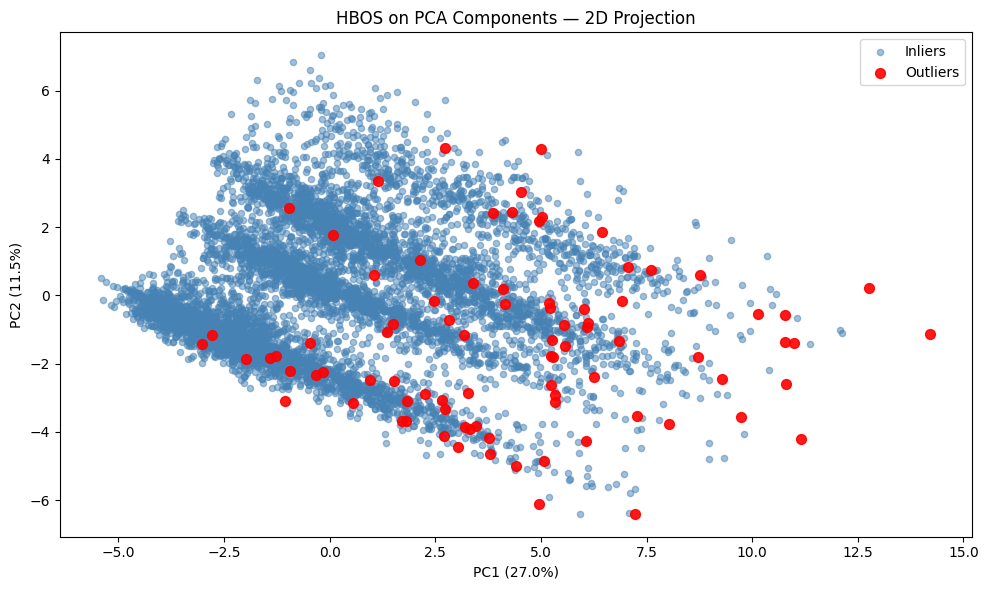

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as PCA_viz

# Reduce to 2D for visualization (using original scaled data for consistency)
pca_viz = PCA_viz(n_components=2)
X_viz = pca_viz.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 6))

# Inliers
ax.scatter(X_viz[df["HBOS_PCA_label"] == 0, 0],
           X_viz[df["HBOS_PCA_label"] == 0, 1],
           c="steelblue", s=20, label="Inliers", alpha=0.5)

# Outliers
ax.scatter(X_viz[df["HBOS_PCA_label"] == 1, 0],
           X_viz[df["HBOS_PCA_label"] == 1, 1],
           c="red", s=50, label="Outliers", alpha=0.9)

ax.set_xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("HBOS on PCA Components — 2D Projection")
ax.legend()
plt.tight_layout()
plt.show()

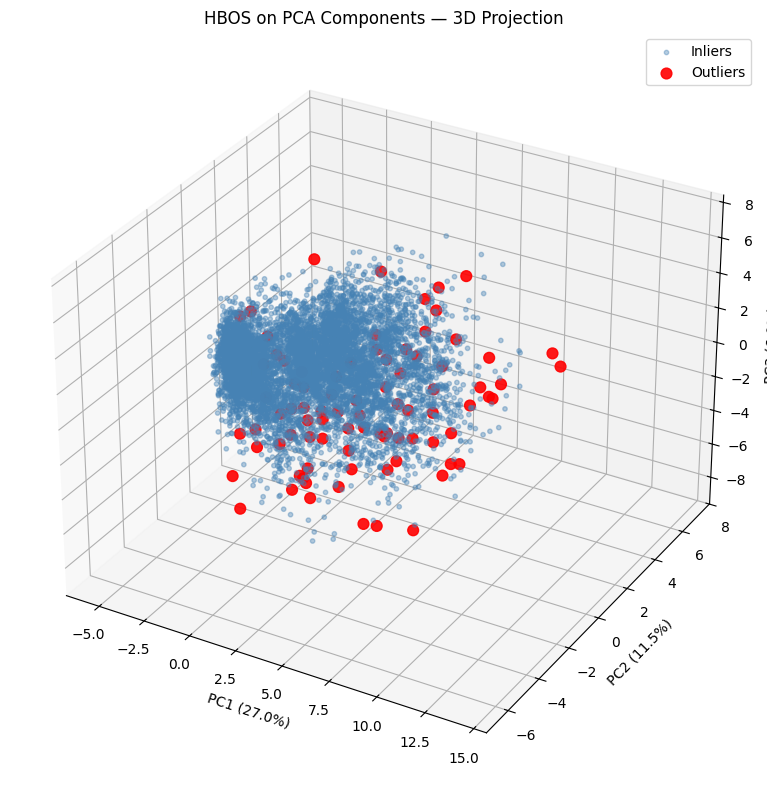

In [7]:
from mpl_toolkits.mplot3d import Axes3D

pca_viz_3d = PCA_viz(n_components=3)
X_viz_3d = pca_viz_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_viz_3d[df["HBOS_PCA_label"] == 0, 0],
           X_viz_3d[df["HBOS_PCA_label"] == 0, 1],
           X_viz_3d[df["HBOS_PCA_label"] == 0, 2],
           c="steelblue", s=10, label="Inliers", alpha=0.4)

ax.scatter(X_viz_3d[df["HBOS_PCA_label"] == 1, 0],
           X_viz_3d[df["HBOS_PCA_label"] == 1, 1],
           X_viz_3d[df["HBOS_PCA_label"] == 1, 2],
           c="red", s=60, label="Outliers", alpha=0.9)

ax.set_xlabel(f"PC1 ({pca_viz_3d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_viz_3d.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca_viz_3d.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("HBOS on PCA Components — 3D Projection")
ax.legend()
plt.tight_layout()
plt.show()

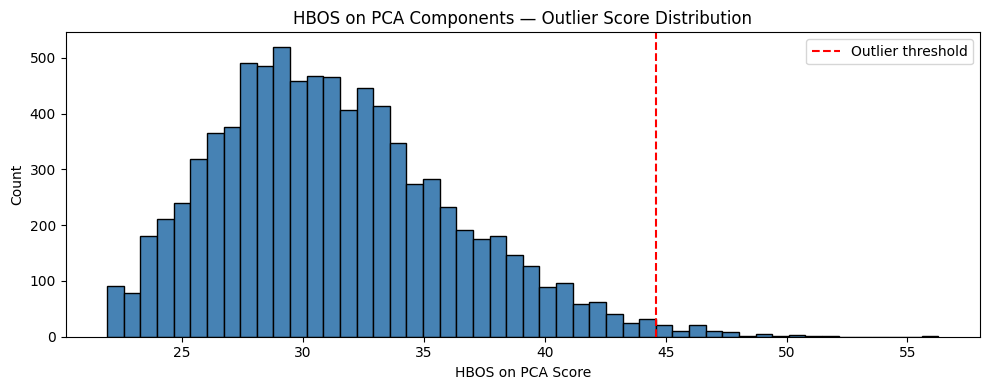

In [8]:
plt.figure(figsize=(10, 4))
plt.hist(df["HBOS_PCA_score"], bins=50, color="steelblue", edgecolor="black")
plt.axvline(df[df["HBOS_PCA_label"] == 1]["HBOS_PCA_score"].min(),
            color="red", linestyle="--", label="Outlier threshold")
plt.xlabel("HBOS on PCA Score")
plt.ylabel("Count")
plt.title("HBOS on PCA Components — Outlier Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
cols_all = X.columns.tolist()

outlier_mean = df[df["HBOS_PCA_label"] == 1][cols_all].mean()
inlier_mean = df[df["HBOS_PCA_label"] == 0][cols_all].mean()
difference = outlier_mean - inlier_mean
pct_difference = (difference / inlier_mean) * 100

comparison_full = pd.DataFrame({
    "Outlier Mean": outlier_mean,
    "Inlier Mean": inlier_mean,
    "Difference": difference,
    "% Difference": pct_difference
}).sort_values("Difference", ascending=False).round(2)

print(comparison_full.to_string())

                                        Outlier Mean  Inlier Mean  Difference  % Difference
Physical-Weight                               145.73        83.92       61.81         73.65
BIA-BIA_FFM                                    84.10        64.27       19.82         30.84
Physical-Systolic_BP                          128.94       115.45       13.49         11.69
FGC_Grip_Avg                                   32.79        20.18       12.61         62.48
BIA-BIA_SMM                                    42.66        30.57       12.08         39.52
Physical-Diastolic_BP                          77.21        68.77        8.44         12.27
Physical-BMI                                   27.55        19.34        8.21         42.44
FGC_Muscular_Endurance                         13.58         6.96        6.62         95.19
Physical-Waist_Circumference                   33.19        26.84        6.35         23.66
BIA-BIA_Fat                                    24.53        18.94        5.59   

In [10]:
print(df[["HBOS_PCA_score", "HBOS_PCA_label"]].sort_values("HBOS_PCA_score", ascending=False).head(10))

      HBOS_PCA_score  HBOS_PCA_label
59         56.279435               1
3688       51.505484               1
4853       50.896347               1
4749       50.509052               1
8300       50.432767               1
1212       50.262360               1
617        49.628845               1
2603       49.380546               1
4007       49.091453               1
3767       48.998607               1


In [11]:
top_outlier_hbos_pca = df[df["HBOS_PCA_label"] == 1].nlargest(1, "HBOS_PCA_score")
print("Top Outlier Row based on HBOS PCA Score:")
print(top_outlier_hbos_pca.to_string())

Top Outlier Row based on HBOS PCA Score:
    Basic_Demos-Age  Basic_Demos-Sex  CGAS-CGAS_Score  Physical-BMI  Physical-Height  Physical-Weight  Physical-Waist_Circumference  Physical-Diastolic_BP  Physical-HeartRate  Physical-Systolic_BP  Fitness_Endurance-Max_Stage  BIA-BIA_Activity_Level_num  BIA-BIA_FFM  BIA-BIA_FFMI  BIA-BIA_FMI  BIA-BIA_Fat  BIA-BIA_Frame_num  BIA-BIA_SMM  SDS-SDS_Total_T  PreInt_EduHx-computerinternet_hoursday  sii  FGC_Flexibility_Avg  FGC_Grip_Avg  PAQ_Total  SDS_measured  BIA_measured  FGC_Muscular_Endurance  Social_Digital_Displacement  Lifestyle_Risk_Score  Metabolic_Alarms_Count  ScreenTime_Age_Ratio  ScreenTime_Category  HBOS_PCA_label  HBOS_PCA_score
59               17                0             65.0     24.446886             68.0            160.8                          33.0                   81.0                56.0                 123.0                          5.0                         4.0      58.8256       14.1834      5.20181      21.5744    

tsne

In [12]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

print("t-SNE done.")

t-SNE done.


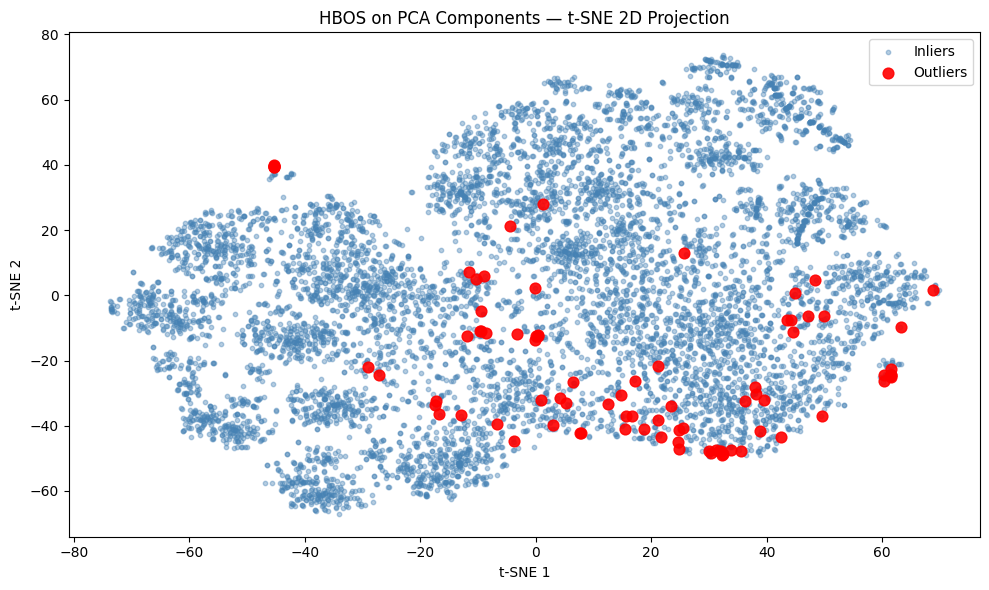

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

# Inliers
ax.scatter(X_tsne[df["HBOS_PCA_label"] == 0, 0],
           X_tsne[df["HBOS_PCA_label"] == 0, 1],
           c="steelblue", s=10, label="Inliers", alpha=0.4)

# Outliers
ax.scatter(X_tsne[df["HBOS_PCA_label"] == 1, 0],
           X_tsne[df["HBOS_PCA_label"] == 1, 1],
           c="red", s=60, label="Outliers", alpha=0.9)

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("HBOS on PCA Components — t-SNE 2D Projection")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
X.nunique().sort_values()

,0
Basic_Demos-Sex,2
SDS_measured,2
BIA-BIA_Frame_num,3
ScreenTime_Category,3
PreInt_EduHx-computerinternet_hoursday,4
BIA-BIA_Activity_Level_num,5
Metabolic_Alarms_Count,6
Basic_Demos-Age,18
Fitness_Endurance-Max_Stage,31
ScreenTime_Age_Ratio,44


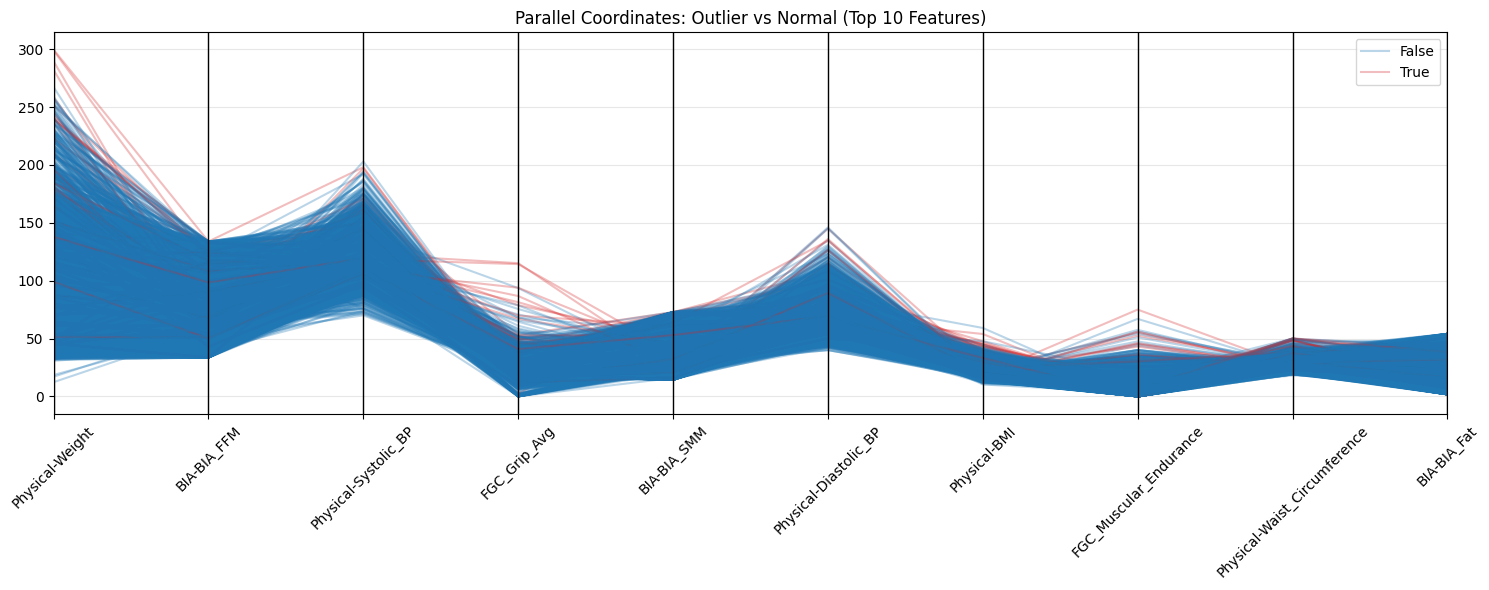

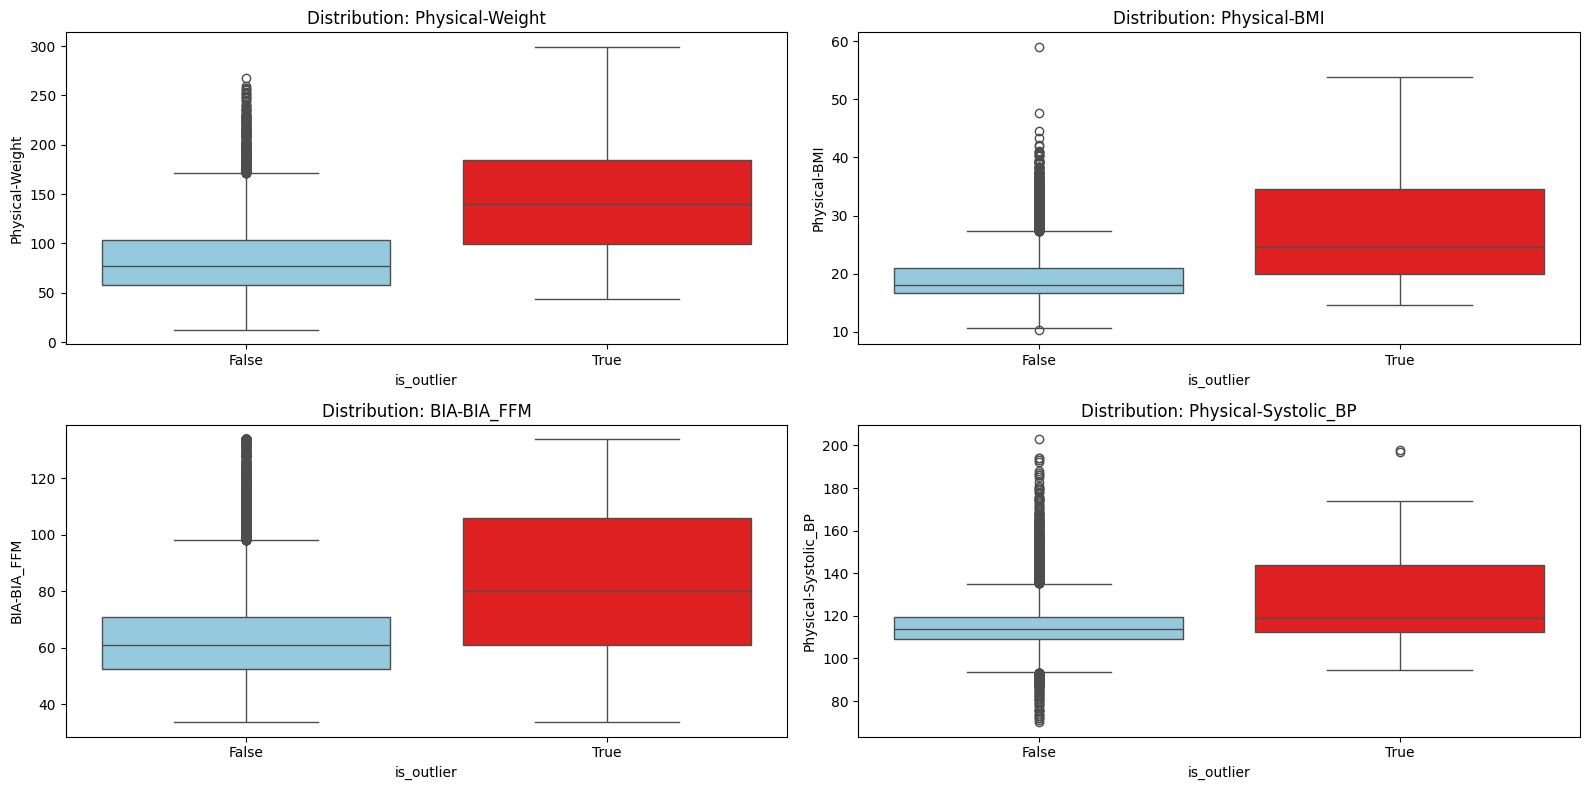

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add is_outlier column as boolean string
df_plot = df.copy()
df_plot['is_outlier'] = df["HBOS_PCA_label"].astype(bool).astype(str)

# 1. Parallel Coordinates Plot (top 10 features by difference)
cols_to_show = [
    "Physical-Weight", "BIA-BIA_FFM", "Physical-Systolic_BP",
    "FGC_Grip_Avg", "BIA-BIA_SMM", "Physical-Diastolic_BP",
    "Physical-BMI", "FGC_Muscular_Endurance", "Physical-Waist_Circumference",
    "BIA-BIA_Fat", "is_outlier"
]

plt.figure(figsize=(15, 6))
pd.plotting.parallel_coordinates(df_plot[cols_to_show], 'is_outlier',
                                  color=['#1f77b4', '#d62728'], alpha=0.3)
plt.title('Parallel Coordinates: Outlier vs Normal (Top 10 Features)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Boxplot of key features
key_features = ['Physical-Weight', 'Physical-BMI', 'BIA-BIA_FFM', 'Physical-Systolic_BP']

plt.figure(figsize=(16, 8))
for i, col in enumerate(key_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='is_outlier', y=col, hue='is_outlier', data=df_plot,
                palette={'True': 'red', 'False': 'skyblue'}, legend=False)
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

In [16]:
print(df[df["HBOS_PCA_label"] == 1].index.tolist())

[59, 87, 306, 356, 436, 489, 580, 617, 632, 636, 672, 896, 921, 943, 994, 1029, 1030, 1212, 1287, 1309, 1470, 1517, 1611, 1629, 1682, 1702, 1976, 2036, 2112, 2174, 2203, 2215, 2263, 2371, 2476, 2549, 2603, 2978, 3001, 3270, 3297, 3333, 3436, 3451, 3456, 3524, 3613, 3688, 3767, 3771, 4007, 4117, 4269, 4399, 4525, 4533, 4593, 4709, 4749, 4853, 5105, 5150, 5243, 5283, 5341, 5389, 5515, 5838, 6078, 6287, 6349, 6407, 6495, 6774, 6891, 6956, 7048, 7111, 7312, 7694, 7849, 7887, 8300, 8342, 8377]


In [17]:
# Save HBOS outlier labels so KNN notebook can load them
df[["HBOS_PCA_label", "HBOS_PCA_score"]].to_csv("hbos_labels.csv", index=True)
print("Saved hbos_labels.csv —", df["HBOS_PCA_label"].sum(), "outliers")

Saved hbos_labels.csv — 85 outliers


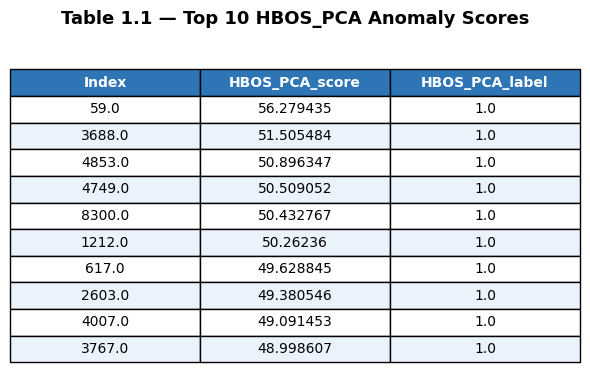

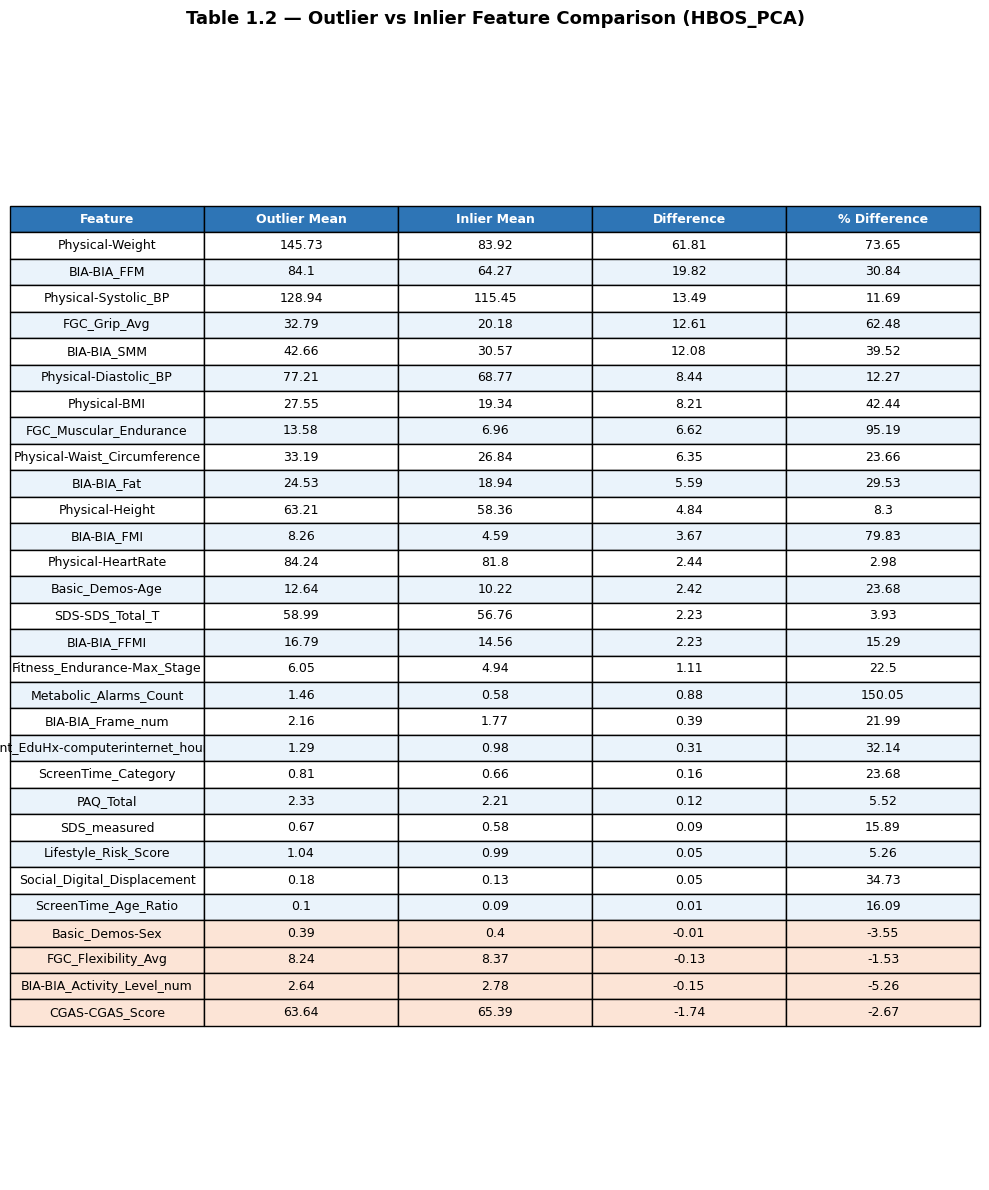

In [18]:
# ── Figure: Table 1.1 — Top 10 HBOS_PCA Anomaly Scores ────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')

table_data = top_outliers_pca[["HBOS_PCA_score", "HBOS_PCA_label"]].reset_index()
table_data.columns = ["Index", "HBOS_PCA_score", "HBOS_PCA_label"]
table_data["HBOS_PCA_score"] = table_data["HBOS_PCA_score"].round(6)

tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)

for i in range(len(table_data.columns)):
    tbl[0, i].set_facecolor('#2E75B6')
    tbl[0, i].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data) + 1):
    color = '#EAF3FB' if i % 2 == 0 else 'white'
    for j in range(len(table_data.columns)):
        tbl[i, j].set_facecolor(color)

plt.title("Table 1.1 — Top 10 HBOS_PCA Anomaly Scores", fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("table_1_1_top10_scores.png", dpi=200, bbox_inches='tight')
plt.show()


# ── Figure: Table 1.2 — Outlier vs Inlier Feature Comparison ──────────────────
comp = comparison_full.reset_index().rename(columns={"index": "Feature"})
comp = comp.sort_values("Difference", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 12))
ax.axis('off')

display_data = comp.copy()
for col in ["Outlier Mean", "Inlier Mean", "Difference", "% Difference"]:
    display_data[col] = display_data[col].round(2)

tbl = ax.table(
    cellText=display_data.values,
    colLabels=display_data.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.3)

for i in range(len(display_data.columns)):
    tbl[0, i].set_facecolor('#2E75B6')
    tbl[0, i].set_text_props(color='white', fontweight='bold')

for i in range(1, len(display_data) + 1):
    is_negative = display_data.loc[i-1, "Difference"] < 0
    color = '#FCE4D6' if is_negative else ('#EAF3FB' if i % 2 == 0 else 'white')
    for j in range(len(display_data.columns)):
        tbl[i, j].set_facecolor(color)

plt.title("Table 1.2 — Outlier vs Inlier Feature Comparison (HBOS_PCA)",
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("table_1_2_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

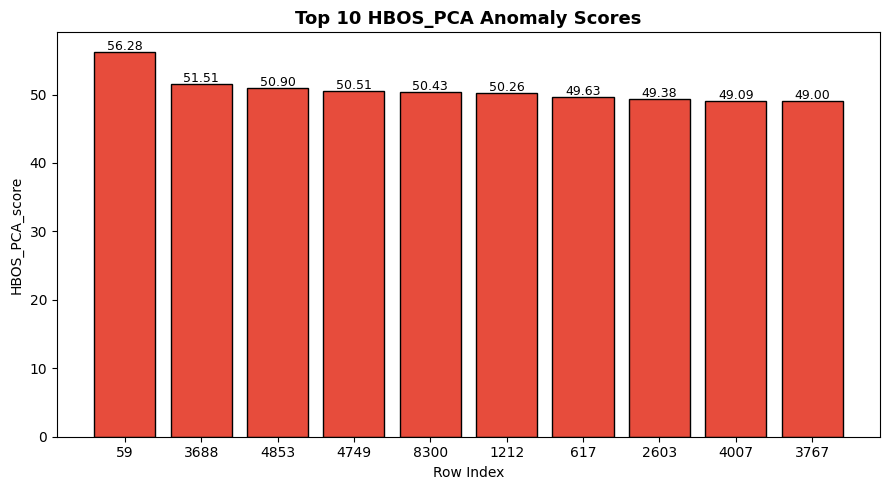

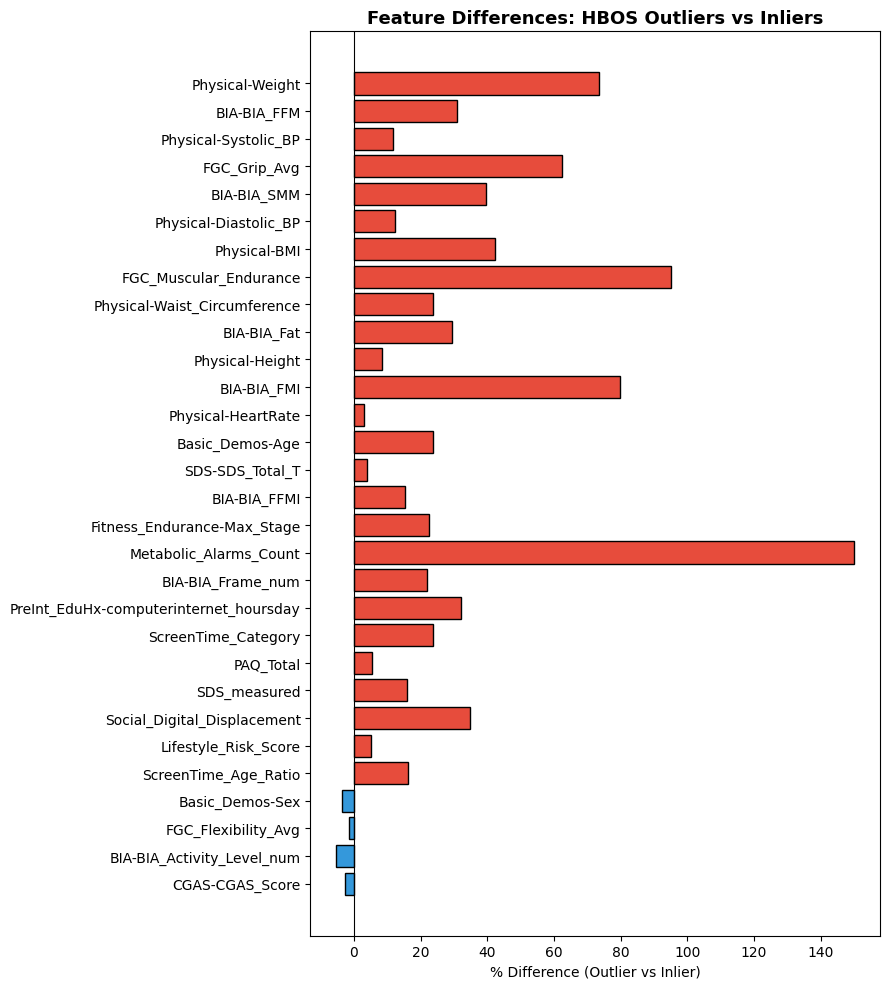

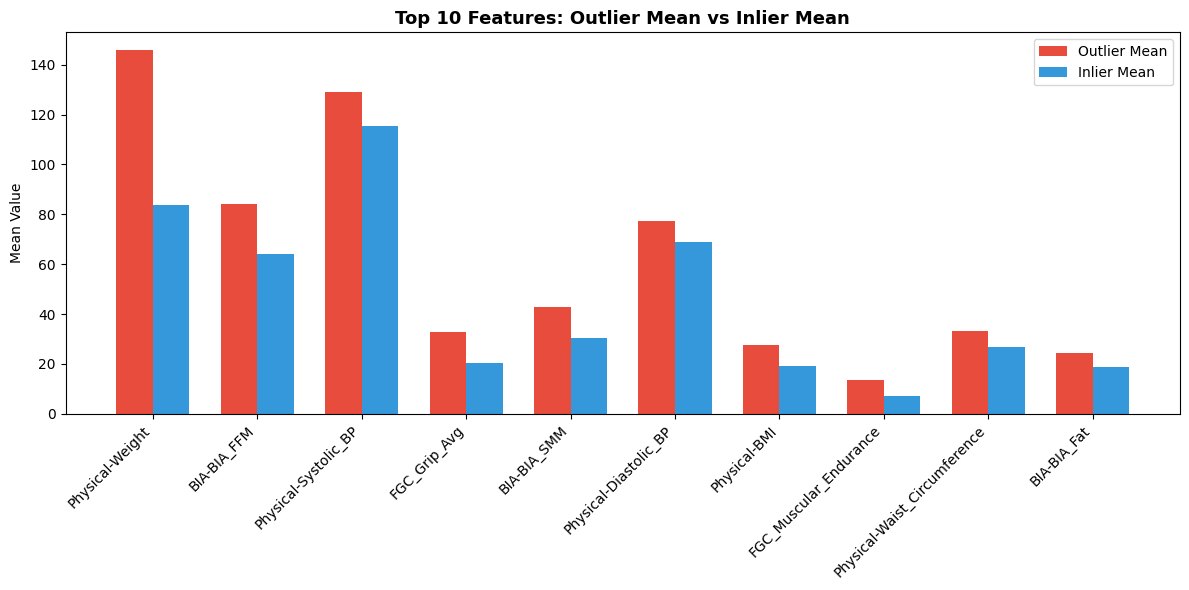

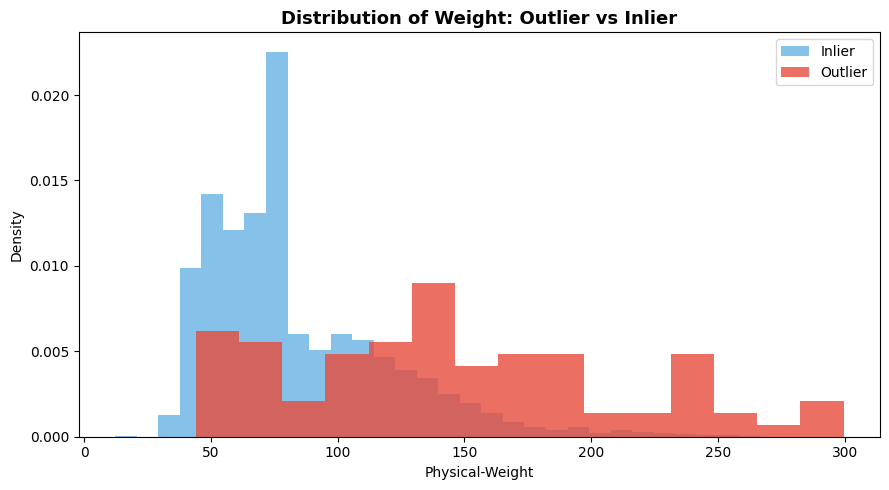

In [19]:
# ── Chart 1: Bar chart — Top 10 HBOS_PCA Anomaly Scores ───────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

top10_scores = df[["HBOS_PCA_score", "HBOS_PCA_label"]].sort_values(
    "HBOS_PCA_score", ascending=False).head(10)

bars = ax.bar(top10_scores.index.astype(str), top10_scores["HBOS_PCA_score"],
              color='#E74C3C', edgecolor='black')
for bar, val in zip(bars, top10_scores["HBOS_PCA_score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', fontsize=9)

ax.set_xlabel("Row Index")
ax.set_ylabel("HBOS_PCA_score")
ax.set_title("Top 10 HBOS_PCA Anomaly Scores", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("chart_top10_scores.png", dpi=150, bbox_inches='tight')
plt.show()


# ── Chart 2: Horizontal bar — % Difference per feature (Outlier vs Inlier) ────
comp_sorted = comparison_full.sort_values("Difference", ascending=True)

colors = ['#E74C3C' if d > 0 else '#3498DB' for d in comp_sorted["Difference"]]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(comp_sorted.index, comp_sorted["% Difference"], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("% Difference (Outlier vs Inlier)")
ax.set_title("Feature Differences: HBOS Outliers vs Inliers", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("chart_pct_difference_all_features.png", dpi=150, bbox_inches='tight')
plt.show()


# ── Chart 3: Grouped bar — Outlier Mean vs Inlier Mean (top 10 by |Difference|) ─
top10_diff = comparison_full.reindex(
    comparison_full["Difference"].abs().sort_values(ascending=False).index
).head(10)

x = np.arange(len(top10_diff))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, top10_diff["Outlier Mean"], width, label='Outlier Mean', color='#E74C3C')
ax.bar(x + width/2, top10_diff["Inlier Mean"],  width, label='Inlier Mean',  color='#3498DB')

ax.set_xticks(x)
ax.set_xticklabels(top10_diff.index, rotation=45, ha='right')
ax.set_ylabel("Mean Value")
ax.set_title("Top 10 Features: Outlier Mean vs Inlier Mean", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("chart_outlier_vs_inlier_top10.png", dpi=150, bbox_inches='tight')
plt.show()


# ── Chart 4: Histogram — distribution of a key feature (Weight), outlier vs inlier ─
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df.loc[df["HBOS_PCA_label"]==0, "Physical-Weight"], bins=30,
        alpha=0.6, color='#3498DB', label='Inlier', density=True)
ax.hist(df.loc[df["HBOS_PCA_label"]==1, "Physical-Weight"], bins=15,
        alpha=0.8, color='#E74C3C', label='Outlier', density=True)

ax.set_xlabel("Physical-Weight")
ax.set_ylabel("Density")
ax.set_title("Distribution of Weight: Outlier vs Inlier", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("chart_weight_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

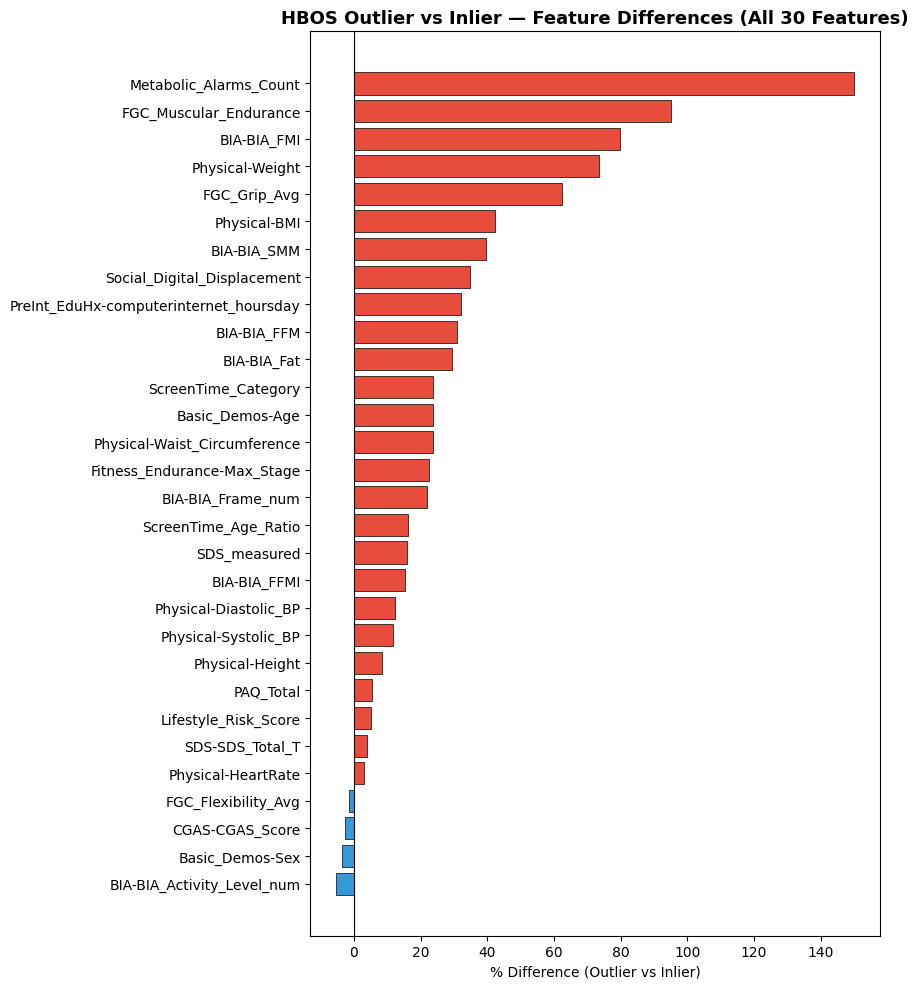

In [20]:
import matplotlib.pyplot as plt

comp_sorted = comparison_full.sort_values("% Difference", ascending=True)
colors = ['#3498DB' if v < 0 else '#E74C3C' for v in comp_sorted["% Difference"]]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(comp_sorted.index, comp_sorted["% Difference"], color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("% Difference (Outlier vs Inlier)")
ax.set_title("HBOS Outlier vs Inlier — Feature Differences (All 30 Features)",
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("hbos_feature_differences_all.png", dpi=150, bbox_inches='tight')
plt.show()

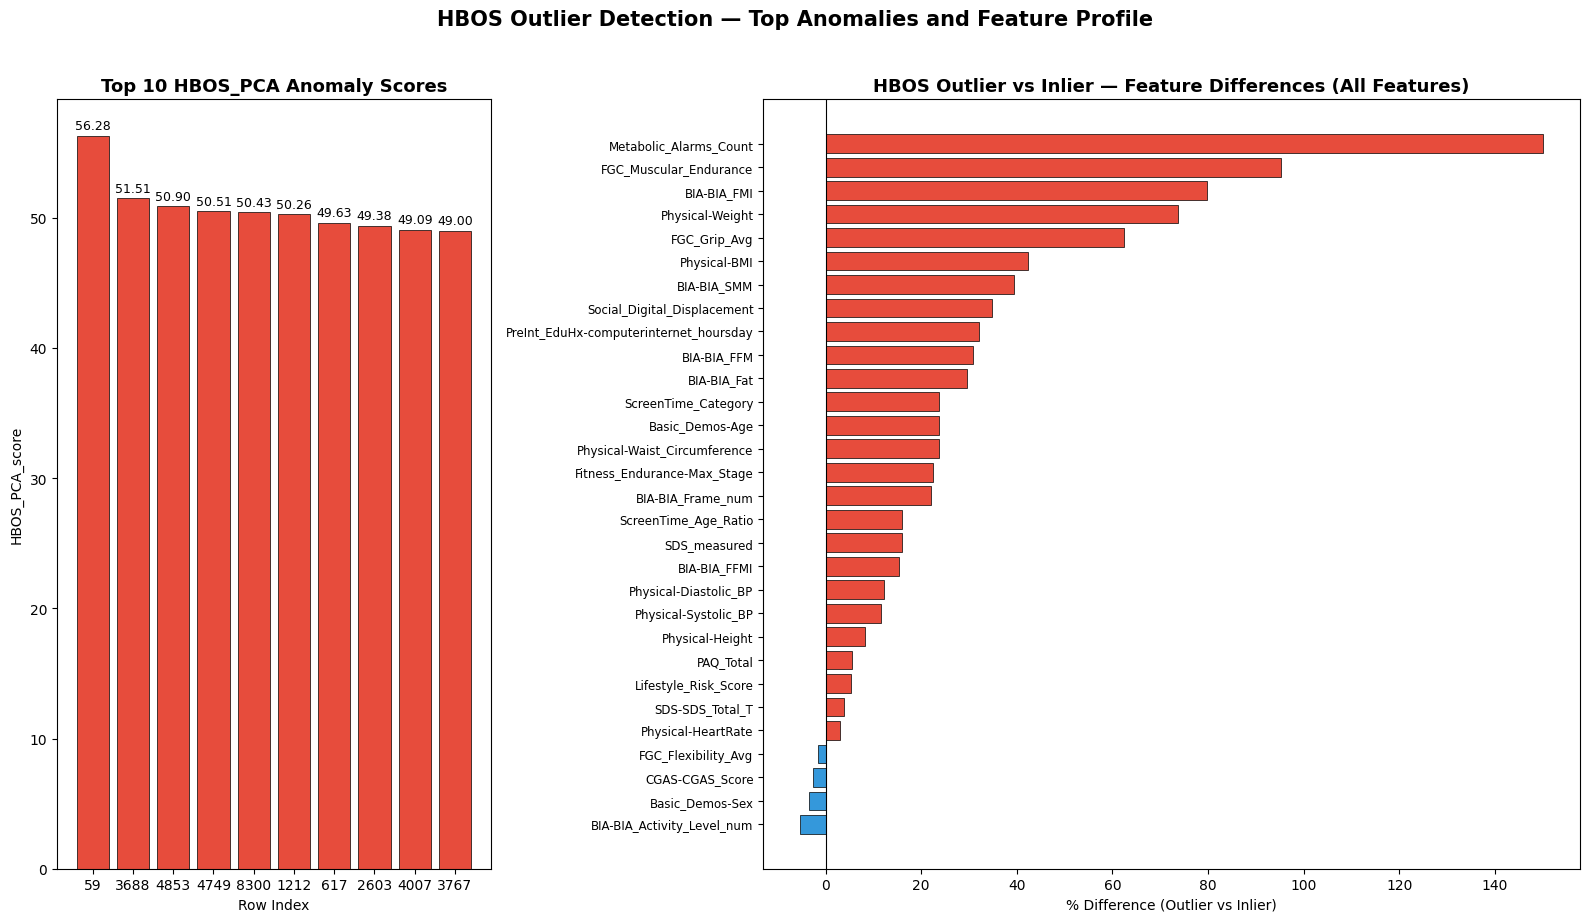

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={'width_ratios': [0.85, 1.6]})

# ── Left: Top 10 HBOS_PCA Anomaly Scores ────────────────────────────────────
ax_top10 = axes[0]

top10 = df[["HBOS_PCA_score", "HBOS_PCA_label"]].sort_values(
    "HBOS_PCA_score", ascending=False).head(10)

bars = ax_top10.bar(top10.index.astype(str), top10["HBOS_PCA_score"],
                     color='#E74C3C', edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, top10["HBOS_PCA_score"]):
    ax_top10.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{val:.2f}', ha='center', fontsize=9)

ax_top10.set_xlabel("Row Index")
ax_top10.set_ylabel("HBOS_PCA_score")
ax_top10.set_title("Top 10 HBOS_PCA Anomaly Scores", fontsize=13, fontweight='bold')

# ── Right: Feature Differences, all features ────────────────────────────────
ax_bar = axes[1]

comp_sorted = comparison_full.sort_values("% Difference", ascending=True)
colors = ['#3498DB' if v < 0 else '#E74C3C' for v in comp_sorted["% Difference"]]

ax_bar.barh(comp_sorted.index, comp_sorted["% Difference"], color=colors,
            edgecolor='black', linewidth=0.5)
ax_bar.axvline(0, color='black', linewidth=0.8)
ax_bar.set_xlabel("% Difference (Outlier vs Inlier)")
ax_bar.set_title("HBOS Outlier vs Inlier — Feature Differences (All Features)",
                  fontsize=13, fontweight='bold')
ax_bar.tick_params(axis='y', labelsize=8.5)

plt.suptitle("HBOS Outlier Detection — Top Anomalies and Feature Profile",
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("hbos_combined.png", dpi=150, bbox_inches='tight')
plt.show()